### Librerias

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

### Carga y drop inicial

In [50]:
df_energyPrice = pd.read_csv("data//XM/Procesadas/price_energy_monthly_2000-2024.csv")

df_nino = pd.read_csv("data/nino34_Index.csv")

df_nino = df_nino[(df_nino['Date'] >= "2000-01-01") & (df_nino['Date'] <= "2024-12-31")]

df_nino.rename(columns={df_nino.columns[1]: 'NINO', df_nino.columns[0]: 'date'}, inplace=True)

df_energyPrice.rename(columns={df_energyPrice.columns[1]: 'ENERGY_PRICE'}, inplace=True)

### Misma Frecuencia (Tecnica Valor Promedio Mensual)

In [52]:
serie_energyPrice = df_energyPrice.copy()
serie_nino = df_nino.copy()

serie_energyPrice['date'] = pd.to_datetime(serie_energyPrice['date'])
serie_nino['date'] = pd.to_datetime(serie_nino['date'])

serie_energyPrice.set_index('date', inplace=True)
serie_nino.set_index('date', inplace=True)

print(serie_energyPrice.head())
print(serie_nino.head())


            ENERGY_PRICE
date                    
2000-01-01     36.778780
2000-02-01     40.261477
2000-03-01     37.637297
2000-04-01     44.298057
2000-05-01     37.291122
            NINO
date            
2000-01-01 -1.79
2000-02-01 -1.53
2000-03-01 -1.26
2000-04-01 -0.80
2000-05-01 -0.80


### Merge

In [53]:
serie = pd.concat(
    [serie_nino, serie_energyPrice],
    axis=1
)

serie.head()

,NINO,ENERGY_PRICE
date,,
2000-01-01,-1.79,36.778780
2000-02-01,-1.53,40.261477
2000-03-01,-1.26,37.637297
2000-04-01,-0.80,44.298057
2000-05-01,-0.80,37.291122


### Visualizacion:

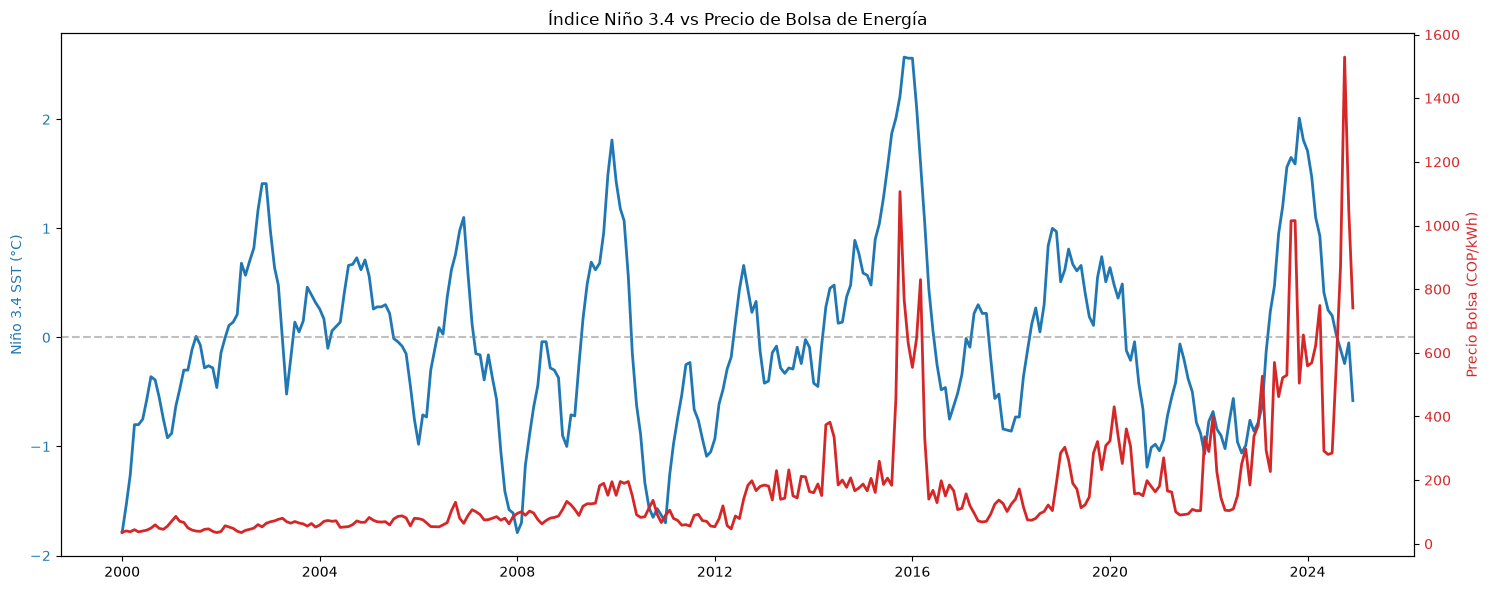

In [61]:
# Crear figura
fig, ax1 = plt.subplots(figsize=(15,6))

# ==========================
# Eje izquierdo (Niño)
# ==========================
ax1.plot(
    serie.index,
    serie["NINO"],
    color="tab:blue",
    linewidth=2,
    label="Niño 3.4"
)

ax1.set_ylabel("Niño 3.4 SST (°C)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Línea horizontal en cero
ax1.axhline(0, color="gray", linestyle="--", alpha=0.5)

# ==========================
# Eje derecho (Precio Energía)
# ==========================
ax2 = ax1.twinx()

ax2.plot(
    serie.index,
    serie["ENERGY_PRICE"],
    color="tab:red",
    linewidth=2,
    label="Precio Energía"
)

ax2.set_ylabel("Precio Bolsa (COP/kWh)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# ==========================
# Título
# ==========================
plt.title("Índice Niño 3.4 vs Precio de Bolsa de Energía")

plt.tight_layout()

plt.show()

In [66]:
output_folder = Path(r"data")

output_folder.mkdir(parents=True, exist_ok=True)

serie.to_csv(
    output_folder / "NINO_PriceEnergy_monthly_2000-2024.csv",
    index=True
)